# 📘 CIFAR-10 Image Classification Learning Project
## Build and Compare **ANN vs CNN** on CIFAR-10

This notebook is designed for **students and beginners** to learn:
- How image classification works
- Why **CNN performs better than ANN**
- How architecture impacts performance
- How training strategies improve results

🎯 **Learning Goal:** Understand the complete DL pipeline by **reading the markdown + running the ready code**.

# 🧠 Problem Statement
Build an image classification model on the **CIFAR-10 dataset** using:

1. **Artificial Neural Network (ANN)**
2. **Convolutional Neural Network (CNN)**

Then compare:
- Accuracy
- Loss curves
- Generalization
- Training strategies (dropout, batch norm, augmentation)

---
### 📦 CIFAR-10 Classes
Airplane, Automobile, Bird, Cat, Deer, Dog, Frog, Horse, Ship, Truck

In [3]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


# 📥 Load Dataset
We use **CIFAR-10**, which contains **60,000 color images of size 32×32×3**.
- 50,000 training images
- 10,000 test images

In [4]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 13s 0us/step
Train shape: (50000, 32, 32, 3)
Test shape: (10000, 32, 32, 3)


## 🖼️ Visualize Sample Images

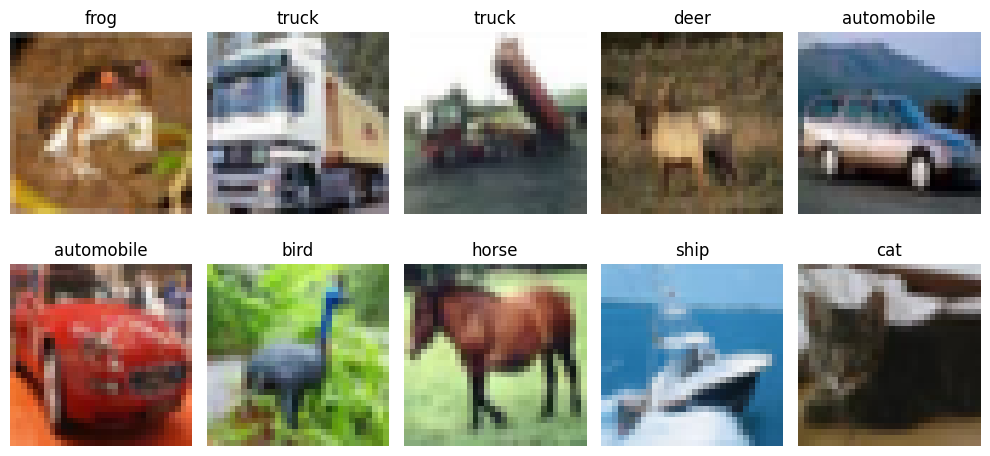

In [5]:
plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")
plt.tight_layout()
plt.show()

# 🧹 Preprocessing
We normalize pixel values from **0–255 → 0–1** so training becomes stable.

In [6]:
x_train_norm = x_train / 255.0
x_test_norm = x_test / 255.0

x_train_flat = x_train_norm.reshape(len(x_train_norm), -1)
x_test_flat = x_test_norm.reshape(len(x_test_norm), -1)

# 🔹 Part 1: ANN Model
ANN treats images as **flat vectors**, so it cannot preserve spatial features.
This helps students understand **why CNN is better for images**.

In [14]:
ann_model = models.Sequential([
    layers.Dense(512, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dense(10, activation='softmax')
])

ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
ann_history = ann_model.fit(
    x_train_flat, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.2711 - loss: 1.9947 - val_accuracy: 0.3346 - val_loss: 1.8542
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3230 - loss: 1.8520 - val_accuracy: 0.3750 - val_loss: 1.7530
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3395 - loss: 1.8058 - val_accuracy: 0.3736 - val_loss: 1.7460
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3518 - loss: 1.7712 - val_accuracy: 0.4036 - val_loss: 1.6953
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3682 - loss: 1.7405 - val_accuracy: 0.3996 - val_loss: 1.7051
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3736 - loss: 1.7217 - val_accuracy: 0.4108 - val_loss: 1.6744
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3781 - loss: 1.7096 - val_accuracy: 0.4126 - val_loss: 1.6633
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3776 - loss: 1.7050 - val_accuracy: 0.

##  Task 1 — Advanced ANN (More Dense Layers)

In [16]:
advanced_ann = models.Sequential([
    tf.keras.Input(shape=(3072,)),

    layers.Dense(512,activation='relu'),
    layers.Dropout(0.3),

    layers.Dense(256,activation='relu'),
    layers.Dropout(0.3),

    layers.Dense(128,activation='relu'),
    layers.Dropout(0.2),

    layers.Dense(64,activation='relu'),
    layers.Dense(10,activation='softmax'),
])

advanced_ann.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
    )

adv_ann_history = advanced_ann.fit(
    x_train_flat, y_train,
    epochs=10,
    validation_split = 0.1,
    batch_size=64
)

adv_ann_loss , adv_ann_acc = advanced_ann.evaluate(x_test_flat,y_test)

print(f"\nAdvanced ANN Test Accuracy : {adv_ann_acc:.4f} ({adv_ann_acc*100:.2f}%)")
print(f" Basic ANN Test Accuracy    : 0.4325 (43.25%)")
print(f" Improvement                : {(adv_ann_acc - 0.4325)*100:.2f}%")

Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - accuracy: 0.2100 - loss: 2.0943 - val_accuracy: 0.2736 - val_loss: 1.9377
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.2729 - loss: 1.9460 - val_accuracy: 0.3054 - val_loss: 1.8766
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.2930 - loss: 1.9057 - val_accuracy: 0.3250 - val_loss: 1.8535
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3040 - loss: 1.8752 - val_accuracy: 0.3402 - val_loss: 1.8233
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3149 - loss: 1.8558 - val_accuracy: 0.3252 - val_loss: 1.8553
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3152 - loss: 1.8538 - val_accuracy: 0.3608 - val_loss: 1.7976
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3245 - loss: 1.8341 - val_accuracy: 0.3516 - val_loss: 1.8024
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3311 - loss: 1.8213 - val_accuracy: 0.

In [17]:
ann_test_loss, ann_test_acc = ann_model.evaluate(x_test_flat, y_test)
print("ANN Test Accuracy:", ann_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.4308 - loss: 1.6384
ANN Test Accuracy: 0.4307999908924103


# 🔹 Part 2: CNN Model
CNN preserves **spatial relationships** using:
- Convolution layers
- Pooling
- Feature extraction
- Hierarchical learning

This is why CNN performs much better for image tasks.

In [15]:
cnn_model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_history = cnn_model.fit(
    x_train_norm, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - accuracy: 0.4784 - loss: 1.4633 - val_accuracy: 0.5750 - val_loss: 1.1723
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.6115 - loss: 1.1065 - val_accuracy: 0.5900 - val_loss: 1.1493
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.6717 - loss: 0.9424 - val_accuracy: 0.6572 - val_loss: 0.9792
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7080 - loss: 0.8333 - val_accuracy: 0.6564 - val_loss: 0.9707
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.7406 - loss: 0.7380 - val_accuracy: 0.5896 - val_loss: 1.2362
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7666 - loss: 0.6597 - val_accuracy: 0.7036 - val_loss: 0.8660
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7890 - loss: 0.5942 - val_accuracy: 0.6992 - val_loss: 0.9163
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8091 - loss: 0.5383 - val_accuracy: 

##  Task 2 — Advanced CNN (Filters 32→64→128)

In [18]:
advanced_cnn = models.Sequential([
    tf.keras.Input(shape=(32,32,3)),

    layers.Conv2D(32,(3,3), activation='relu', padding = 'same'),
    layers.BatchNormalization(),

    layers.Conv2D(32,(3,3), activation='relu', padding = 'same'),
    layers.BatchNormalization(),

    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.25),

    layers.Conv2D(64,(3,3), activation='relu', padding = 'same'),
    layers.BatchNormalization(),

    layers.Conv2D(64,(3,3), activation='relu', padding = 'same'),
    layers.BatchNormalization(),

    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.25),

    layers.Conv2D(128,(3,3), activation='relu', padding = 'same'),
    layers.BatchNormalization(),

    layers.Conv2D(128,(3,3), activation='relu', padding = 'same'),
    layers.BatchNormalization(),

    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.25),

    layers.Flatten(),

    layers.Dense(128,activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),

    layers.Dense(10,activation='softmax')

])
advanced_cnn.summary()

advanced_cnn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

adv_cnn_history = advanced_cnn.fit(
    x_train_norm, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

adv_cnn_loss, adv_cnn_acc = advanced_cnn.evaluate(x_test_norm, y_test)
print(f"\n Advanced CNN Test Accuracy : {adv_cnn_acc:.4f} ({adv_cnn_acc*100:.2f}%)")
print(f" Basic CNN Test Accuracy    : 0.7209 (72.09%)")
print(f" Improvement                : {(adv_cnn_acc - 0.7209)*100:.2f}%")

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_17          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 552,874 (2.11 MB)

 Trainable params: 551,722 (2.10 MB)

 Non-trainable params: 1,152 (4.50 KB)

Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 27s 21ms/step - accuracy: 0.4329 - loss: 1.6606 - val_accuracy: 0.5860 - val_loss: 1.1485
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.6138 - loss: 1.0922 - val_accuracy: 0.6914 - val_loss: 0.8747
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.6844 - loss: 0.9014 - val_accuracy: 0.7282 - val_loss: 0.7882
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.7276 - loss: 0.7848 - val_accuracy: 0.7274 - val_loss: 0.7819
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.7530 - loss: 0.7145 - val_accuracy: 0.7724 - val_loss: 0.6485
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.7719 - loss: 0.6562 - val_accuracy: 0.7742 - val_loss: 0.6665
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.7924 - loss: 0.6016 - val_accuracy: 0.8090 - val_loss: 0.5716
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.8099 - loss: 0.5575 - val_accura

##  Task 3 & 4 — EarlyStopping + 20 Epochs

In [19]:
early_stop = tf.keras.callbacks.EarlyStopping(

    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

print("🚀 Training Advanced CNN with EarlyStopping (20 epochs)...")

adv_cnn_es_history = advanced_cnn.fit(
    x_train_norm, y_train,

    epochs=20,

    validation_split=0.1,
    batch_size=64,

    callbacks=[early_stop]
)


adv_cnn_es_loss, adv_cnn_es_acc = advanced_cnn.evaluate(
    x_test_norm, y_test
)
print(f"\n Advanced CNN (20 epochs + EarlyStopping) : {adv_cnn_es_acc:.4f} ({adv_cnn_es_acc*100:.2f}%)")
print(f" Basic CNN (10 epochs)                    : {cnn_test_acc:.4f} ({cnn_test_acc*100:.2f}%)")
print(f" Improvement                              : {(adv_cnn_es_acc - cnn_test_acc)*100:.2f}%")

🚀 Training Advanced CNN with EarlyStopping (20 epochs)...
Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.8411 - loss: 0.4606 - val_accuracy: 0.8292 - val_loss: 0.5177
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.8538 - loss: 0.4292 - val_accuracy: 0.8362 - val_loss: 0.4901
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.8586 - loss: 0.4124 - val_accuracy: 0.8382 - val_loss: 0.4956
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.8660 - loss: 0.3912 - val_accuracy: 0.8268 - val_loss: 0.5404
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.8688 - loss: 0.3781 - val_accuracy: 0.8488 - val_loss: 0.4699
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.8774 - loss: 0.3559 - val_accuracy: 0.8420 - val_loss: 0.5006
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.8830 - loss: 0.3391 - val_accuracy: 0.8400 - val_loss: 0.5053
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 7s

In [20]:
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(x_test_norm, y_test)
print("CNN Test Accuracy:", cnn_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6854 - loss: 1.1108
CNN Test Accuracy: 0.6854000091552734


## 📈 Compare Learning Curves

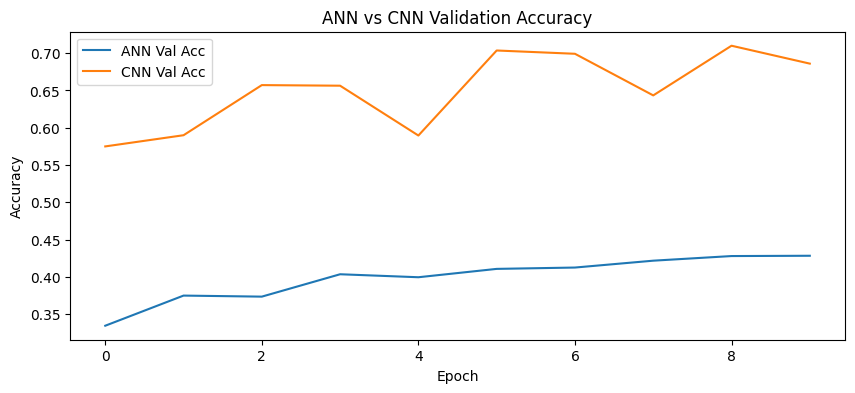

In [21]:
plt.figure(figsize=(10,4))
plt.plot(ann_history.history['val_accuracy'], label='ANN Val Acc')
plt.plot(cnn_history.history['val_accuracy'], label='CNN Val Acc')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ANN vs CNN Validation Accuracy")
plt.legend()
plt.show()

# 🚀 Training Strategy Upgrade: Data Augmentation
This strategy improves generalization by generating transformed images.

In [26]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

aug_cnn_model = models.Sequential([
    data_augmentation,
    layers.Conv2D(32, 3, activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

aug_cnn_model.compile(optimizer='adam',
                      loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])

# Suggested optional run:
# aug_history = aug_cnn_model.fit(x_train_norm, y_train, epochs=10, validation_split=0.1)

# Augmented CNN train
aug_history = aug_cnn_model.fit(
    x_train_norm, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

# evaluate
aug_loss, aug_acc = aug_cnn_model.evaluate(x_test_norm, y_test)
print(f"\n📌 Augmented CNN Accuracy : {aug_acc*100:.2f}%")
print(f"📌 Basic CNN Accuracy     : {cnn_test_acc*100:.2f}%")



Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.3575 - loss: 1.7546 - val_accuracy: 0.4736 - val_loss: 1.4695
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.4540 - loss: 1.5127 - val_accuracy: 0.4876 - val_loss: 1.3995
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.4933 - loss: 1.4239 - val_accuracy: 0.5690 - val_loss: 1.1990
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.5176 - loss: 1.3584 - val_accuracy: 0.5474 - val_loss: 1.2812
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.5345 - loss: 1.3125 - val_accuracy: 0.5910 - val_loss: 1.1212
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.5500 - loss: 1.2710 - val_accuracy: 0.6024 - val_loss: 1.1267
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.5606 - loss: 1.2489 - val_accuracy: 0.6192 - val_loss: 1.1024
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.5712 - loss: 1.2187 - val_accuracy: 0.

# 📊 Final Comparison Table

📊 Final Model Comparison:
                          Model  Test Accuracy (%)                 Type
0  Advanced CNN + EarlyStopping              83.33  CNN + EarlyStopping
1                     Basic CNN              68.54                  CNN
2                 Augmented CNN              63.23   CNN + Augmentation
3                     Basic ANN              43.08                  ANN
4                  Advanced ANN              37.74                  ANN


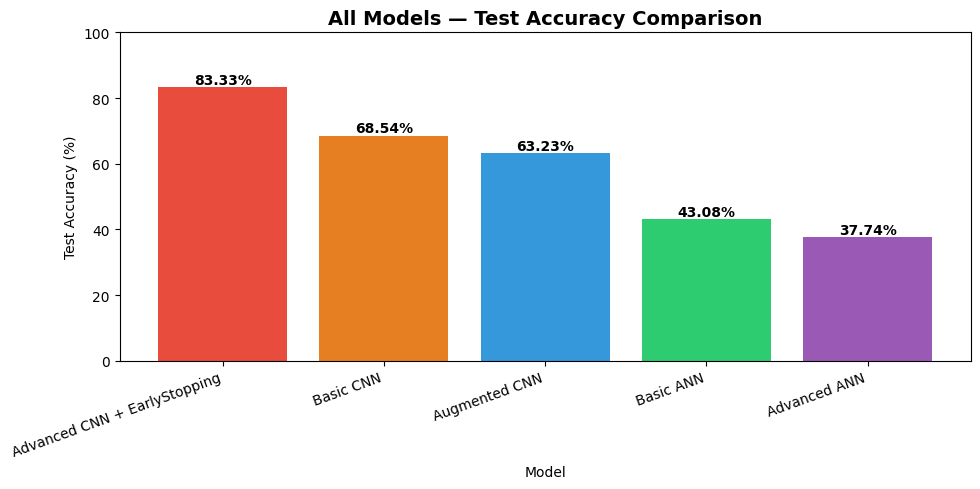

In [27]:

comparison = pd.DataFrame({
    "Model": [
        "Basic ANN",
        "Advanced ANN",
        "Basic CNN",
        "Advanced CNN + EarlyStopping",
        "Augmented CNN"
    ],
    "Test Accuracy (%)": [
        round(ann_test_acc * 100, 2),
        round(adv_ann_acc * 100, 2),
        round(cnn_test_acc * 100, 2),
        round(adv_cnn_es_acc * 100, 2),
        round(aug_acc * 100, 2)
    ],
    "Type": [
        "ANN",
        "ANN",
        "CNN",
        "CNN + EarlyStopping",
        "CNN + Augmentation"
    ]
})

# sort by accuracy
comparison = comparison.sort_values(
    "Test Accuracy (%)", ascending=False
).reset_index(drop=True)

print(" Final Model Comparison:")
print(comparison)

# Bar Plot
plt.figure(figsize=(10, 5))
plt.bar(comparison["Model"],
        comparison["Test Accuracy (%)"],
        color=['#e74c3c','#e67e22','#3498db','#2ecc71','#9b59b6'])
plt.title("All Models — Test Accuracy Comparison",
          fontsize=14, fontweight='bold')
plt.xlabel("Model")
plt.ylabel("Test Accuracy (%)")
plt.xticks(rotation=20, ha='right')
plt.ylim(0, 100)
for i, v in enumerate(comparison["Test Accuracy (%)"]):
    plt.text(i, v + 1, f"{v}%", ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

# 📋 Final Summary

| Step | What We Did |
|---|---|
| **Dataset** | Loaded CIFAR-10 — 50,000 train images, 10,000 test images (32×32×3 color) |
| **Preprocessing** | Normalized pixel values 0–255 → 0–1.0 for stable gradient updates |
| **ANN (Baseline)** | Flat vector input → Dense + Dropout layers → 43.08% accuracy |
| **Advanced ANN** | Added more Dense layers (512→256→128→64) → 37.74% (more layers ≠ better for images) |
| **CNN (Baseline)** | Conv2D + BatchNorm + MaxPooling + Flatten → 68.54% accuracy |
| **Advanced CNN** | Scaled filters 32→64→128 with double Conv blocks → stronger feature extraction |
| **EarlyStopping** | Monitored val_loss, patien

# ✅ Conclusion
- **ANN works**, but ignores image structure
- **CNN extracts spatial features**, so it performs significantly better
- **Training strategies** like dropout, batch norm, and augmentation improve results
- This project builds strong fundamentals for **computer vision interviews and deep learning projects**